In [1]:
%reset -f

In [2]:
import numpy as np
from tqdm import tqdm
import scipy.linalg as la
import numpy.linalg as npla

import torch
import normflows as nf

import sys
sys.path.append('/Users/adithya/Documents/flow-pid')
import pid
import pid.utils.distributions as dist
from pid.utils.generate import sample_mult_poisson
from pid.utils.custom_flow import CartesianProductFlow

In [3]:
def get_params():
    lamda_m = np.array([2., 2.])
    lamda_x = np.array([1.,])      # Noise to be added to X: shape (d_X,)
    lamda_y = np.array([1.,])

    w_x1_vals = np.arange(11) / 10
    w_x2 = 0.5
    w_y1 = 0.5
    w_y2 = 0.5

    return lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2

In [4]:
def objective(sig, hx, hy, dm, dx, dy, reg):
    S = (1 + reg) * np.eye(dx) - sig @ sig.T
    B = hx - sig @ hy
    obj = 0.5 / np.log(2) * npla.slogdet(
        np.eye(dm) + hy.T @ hy + B.T @ la.solve(S, B)
    )[1]
    return obj

def covariance_to_correlation(covariance_matrix):
    covariance_matrix = np.array(covariance_matrix)
    
    if covariance_matrix.shape[0] != covariance_matrix.shape[1]:
        raise ValueError("Covariance matrix must be square")
    
    if not np.allclose(covariance_matrix, covariance_matrix.T):
        raise ValueError("Covariance matrix must be symmetric")
    
    std_devs = np.sqrt(np.diag(covariance_matrix))  
    outer_std = np.outer(std_devs, std_devs)
    correlation_matrix = covariance_matrix / outer_std 
    np.fill_diagonal(correlation_matrix, 1.0)
    
    return correlation_matrix

In [5]:
num_samples=1000
flow_iter=1000
n_flows=1

enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2 = get_params()
dm = lamda_m.size  # Number of dimensions of M
dx = lamda_x.size  # Number of dimensions of X
dy = lamda_y.size  # Number of dimensions of Y

Using device: cpu


In [9]:
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt



def train_flow(m_data, x_data, y_data, n_epochs=100, batch_size=64, lr=2e-4):
    # Initialize model
    dim_x, dim_y, dim_m = x_data.shape[1], y_data.shape[1], m_data.shape[1]
    flow = CartesianProductFlow(dim_m, dim_x, dim_y, n_flows)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    
    # Create dataset
    print(x_data.shape, y_data.shape, m_data.shape)
    dataset = TensorDataset(torch.tensor(x_data,dtype=torch.float32), torch.tensor(y_data,dtype=torch.float32), torch.tensor(m_data,dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    for epoch in tqdm(range(n_epochs)):
        epoch_losses = []
        
        for x_batch, y_batch, m_batch in dataloader:
            optimizer.zero_grad()
            
            # Forward pass
            z_m, z_x, z_y, log_det = flow(m_batch, x_batch, y_batch)
            
            # Compute loss
            loss = flow.compute_loss(z_m, z_x, z_y, log_det)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        
        with torch.no_grad():
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")
                
                # Print learned parameters
                # print(f"Learned mean: {flow.estimate_latent_mean(z_m, z_x, z_y).data}")
                # print(f"Learned covariance:\n{flow.estimate_latent_cov(z_m, z_x, z_y).data}")

                if epoch > 30:
                    cov = flow.estimate_latent_cov(z_m, z_x, z_y).detach().cpu().numpy()
                    cov = covariance_to_correlation(cov)
                    print(f"Learned covariance:\n{cov}")
                    # ret = pid.utils.whiten(cov, dm, dx, dy, ret_channel_params=True)
                    # sig_mxy, hx, hy, hxy, sigxy = ret
                    # sig, obj, _ = pid.optimizers.thinpid_exact_pid_minimizer(hx, hy, ret_obj=True, reg=1e-7)
                    # union_info = objective(sig, hx, hy, dm, dx, dy, reg=1e-7)
                    # print(f"Union information:{union_info}")
                    ret = exact_gauss_tilde_pid(cov, dm, dx, dy)

                    print("pid: ", ret[7], ret[5], ret[6], ret[8])
    
    # Plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    
    return flow, losses

(1000, 1) (1000, 1) (1000, 2)


  0%|          | 0/1000 [00:00<?, ?it/s]

  6%|▌         | 60/1000 [00:00<00:14, 65.35it/s]

Epoch 50/1000, Loss: 29.6591
Learned covariance:
[[ 1.         -0.17304982  0.61878     0.34903497]
 [-0.17304982  1.          0.21558857  0.3264155 ]
 [ 0.61878     0.21558857  1.          0.3454315 ]
 [ 0.34903497  0.3264155   0.3454315   1.        ]]
pid:  0.18610312107695703 0.29992043890340514 0.046937000655927374 0.09444671607911592


 11%|█         | 108/1000 [00:01<00:12, 73.75it/s]

...

Epoch 900/1000, Loss: 19.7274
Learned covariance:
[[1.         0.04969304 0.54569787 0.28961083]
 [0.04969304 1.         0.44157583 0.45642287]
 [0.54569787 0.44157583 1.         0.34239498]
 [0.28961083 0.45642287 0.34239498 1.        ]]
pid:  0.1906102200738562 0.2673404964221541 0.04610480447281662 0.10066231471614628


 96%|█████████▌| 957/1000 [00:13<00:00, 68.98it/s]

Epoch 950/1000, Loss: 18.8977
Learned covariance:
[[1.         0.00616225 0.53897834 0.27868858]
 [0.00616225 1.         0.434633   0.4314298 ]
 [0.53897834 0.434633   1.         0.33912215]
 [0.27868858 0.4314298  0.33912215 1.        ]]
pid:  0.1830951909459101 0.28382171923526867 0.03637829382818719 0.09499039061154513


100%|██████████| 1000/1000 [00:14<00:00, 69.78it/s]

Epoch 1000/1000, Loss: 21.7966
Learned covariance:
[[1.         0.01471004 0.5297216  0.27348238]
 [0.01471004 1.         0.4404609  0.44054532]
 [0.5297216  0.4404609  1.         0.3377996 ]
 [0.27348238 0.44054532 0.3377996  1.        ]]
pid:  0.1836100116151625 0.27143455035468933 0.0388604971598579 0.09624073302734498


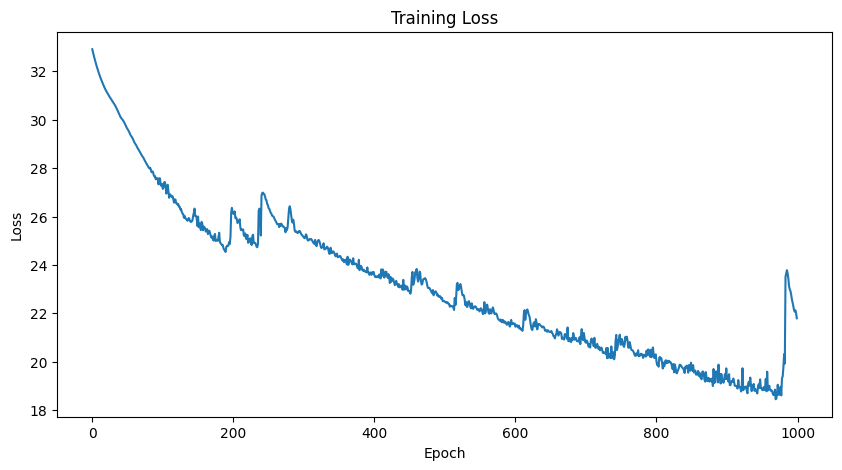

In [13]:
w_x1 = w_x1_vals[9]
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])
m, x, y = sample_mult_poisson(num_samples, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)


trained_flow, training_losses = train_flow(m.T, x.T, y.T, n_epochs=1000, batch_size=1000, lr=1e-4)

(1000, 1) (1000, 1) (1000, 2)


  6%|▌         | 58/1000 [00:00<00:14, 65.68it/s]

Epoch 50/1000, Loss: 22.7079
Learned covariance:
[[ 1.         -0.27611643 -0.08838294  0.3336817 ]
 [-0.27611643  1.          0.49104536  0.3353855 ]
 [-0.08838294  0.49104536  1.          0.23500289]
 [ 0.3336817   0.3353855   0.23500289  1.        ]]
pid:  0.06058230422734684 0.14074744486887886 0.2062497865817669 0.022861171830164673


 11%|█         | 108/1000 [00:01<00:13, 66.18it/s]

Epoch 100/1000, Loss: 20.5969
Learned covariance:
[[ 1.         -0.05004009 -0.01375861  0.39090252]
 [-0.05004009  1.          0.49839476  0.36463964]
 [-0.01375861  0.49839476  1.          0.23148267]
 [ 0.39090252  0.36463964  0.23148267  1.        ]]
pid:  0.060989093723132326 0.1451101083534832 0.19710722220327595 0.024067511272815645


...

Epoch 900/1000, Loss: 13.9036
Learned covariance:
[[1.         0.16801475 0.0146165  0.41071725]
 [0.16801475 1.         0.48963463 0.4405562 ]
 [0.0146165  0.48963463 1.         0.2288279 ]
 [0.41071725 0.4405562  0.2288279  1.        ]]
pid:  0.06480068046328064 0.1374011169799672 0.20364745029446657 0.027857919798569497


 96%|█████████▌| 958/1000 [00:13<00:00, 74.77it/s]

Epoch 950/1000, Loss: 14.1499
Learned covariance:
[[1.         0.15029015 0.01873278 0.4122737 ]
 [0.15029015 1.         0.4838936  0.4351326 ]
 [0.01873278 0.4838936  1.         0.23910555]
 [0.4122737  0.4351326  0.23910555 1.        ]]
pid:  0.06483497852006687 0.13041560771265293 0.20539141861418567 0.025505775483274484


100%|██████████| 1000/1000 [00:14<00:00, 70.25it/s]

Epoch 1000/1000, Loss: 13.6640
Learned covariance:
[[1.         0.16986716 0.02749687 0.42316404]
 [0.16986716 1.         0.47993186 0.44072613]
 [0.02749687 0.47993186 1.         0.2408059 ]
 [0.42316404 0.44072613 0.2408059  1.        ]]
pid:  0.06493438847713356 0.12673646968073848 0.2123677866947658 0.02512363678295454


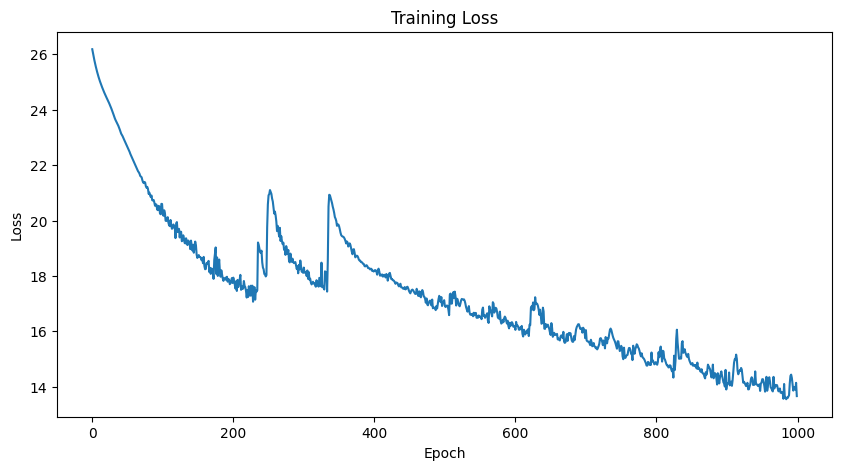

In [15]:
w_x1 = w_x1_vals[0]
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])
m, x, y = sample_mult_poisson(num_samples, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)


trained_flow, training_losses = train_flow(m.T, x.T, y.T, n_epochs=1000, batch_size=1000, lr=1e-4)

In [16]:
from pid.optimizers import exact_gauss_tilde_pid, exact_tilde_union_info_minimizer
from pid.utils import whiten

mxy = np.vstack((m, x, y))
cov = np.corrcoef(mxy)    # Shape: (dm+dx+dy, dm+dx+dy)
print(cov)

# ret = whiten(cov, dm, dx, dy, ret_channel_params=True)
# sig_mxy, hx, hy, hxy, sigxy = ret
# print(sig_mxy)
# print(hx, hy)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
# union_info = objective(sig, hx, hy, dm, dx, dy, reg=1e-7)

# print(union_info)
print(ret[7], ret[5], ret[6], ret[8])

[[ 1.          0.00639344 -0.01173226  0.40867583]
 [ 0.00639344  1.          0.5057621   0.42691012]
 [-0.01173226  0.5057621   1.          0.23252025]
 [ 0.40867583  0.42691012  0.23252025  1.        ]]
0.0720564336768581 0.1412750051314441 0.23542297109812535 0.03272664657540347
